Dataset-->


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path='/content/drive/MyDrive/dataset/DSB_Mali_Cleaned_Dataset.xlsx'
df=pd.read_excel(path)
df.head(50)

,Period,Reporter,Partner,Comodity_Code,Qauntity_Unit,Quantity,Value
0,2017,Mali,World,7108,kg,30512.13,1.254096e+09
1,2017,Mali,South Africa,7108,kg,18775.50,7.776511e+08
2,2017,Mali,World,710812,kg,30512.13,1.254096e+09
3,2017,Mali,India,7108,kg,732.88,2.996141e+07
4,2017,Mali,United Arab Emirates,7108,kg,867.98,2.914061e+07
5,2017,Mali,Switzerland,7108,kg,9705.32,4.019791e+08
6,2017,Mali,South Africa,710812,kg,18775.50,7.776511e+08
7,2017,Mali,Spain,7108,kg,1.14,3.031588e+04
8,2017,Mali,Belgium,7108,kg,6.00,1.587510e+05
9,2017,Mali,Türkiye,7108,kg,423.31,1.517450e+07


missing values (if any)

In [ ]:
df['Value'].fillna(0, inplace=True)

In [ ]:
print(df.dtypes)

Period             int64
Reporter          object
Partner           object
Comodity_Code      int64
Qauntity_Unit     object
Quantity         float64
Value            float64
dtype: object


statistic


In [ ]:
df_filtered = df[df['Period'].isin([2017, 2018, 2019, 2020, 2021, 2022, 2023])]


In [ ]:
print(df_filtered.describe())


            Period  Comodity_Code      Quantity         Value
count    50.000000      50.000000     50.000000  5.000000e+01
mean   2017.960000  358960.000000  12625.213600  5.249664e+08
std       0.781417  355424.193106  19624.145746  8.178389e+08
min    2017.000000    7108.000000      1.000000  2.799255e+04
25%    2017.000000    7108.000000     26.000000  9.860605e+05
50%    2018.000000  358960.000000    567.020000  1.913551e+07
75%    2019.000000  710812.000000  29083.000000  1.242057e+09
max    2019.000000  710812.000000  65670.040000  2.657101e+09


In [ ]:
partner_totals = df_filtered.groupby('Partner')['Value'].sum().reset_index()
print(partner_totals)

                        Partner         Value
0                     Australia  1.460833e+07
1                       Belgium  3.175020e+05
2          China, Hong Kong SAR  1.164537e+07
3   Dem. People's Rep. of Korea  1.972121e+06
4                        France  4.938044e+06
5                         Ghana  1.522047e+06
6                         India  5.992282e+07
7                      Portugal  5.598510e+04
8                  South Africa  6.936441e+09
9                         Spain  1.166169e+05
10                  Switzerland  5.882942e+09
11                      Türkiye  3.271556e+07
12         United Arab Emirates  1.769617e+08
13                        World  1.312416e+10


In [ ]:
top_partners = partner_totals.nlargest(10, 'Value')
print(top_partners)

                        Partner         Value
13                        World  1.312416e+10
8                  South Africa  6.936441e+09
10                  Switzerland  5.882942e+09
12         United Arab Emirates  1.769617e+08
6                         India  5.992282e+07
11                      Türkiye  3.271556e+07
0                     Australia  1.460833e+07
2          China, Hong Kong SAR  1.164537e+07
4                        France  4.938044e+06
3   Dem. People's Rep. of Korea  1.972121e+06


<ipython-input-14-3bf7f0ded9f2>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_partners, x='Value', y='Partner', palette='viridis')


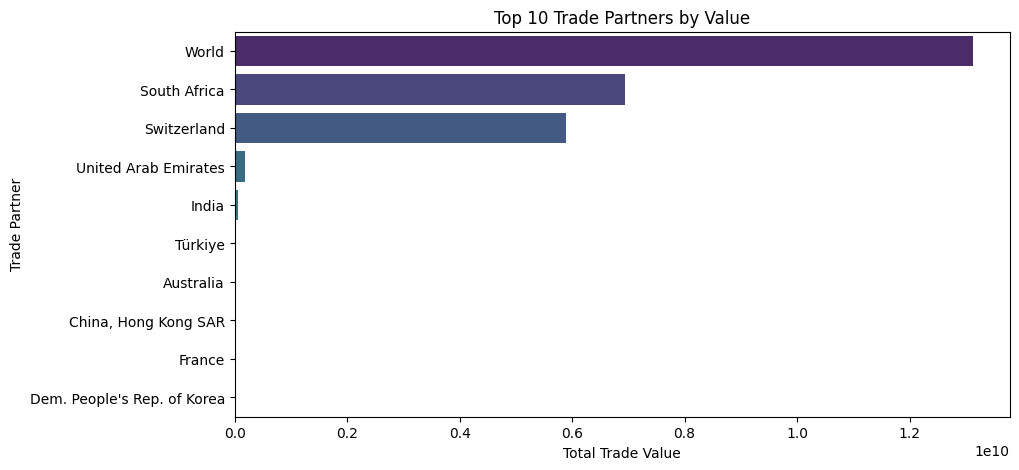

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 5))
sns.barplot(data=top_partners, x='Value', y='Partner', palette='viridis')
plt.xlabel("Total Trade Value")
plt.ylabel("Trade Partner")
plt.title("Top 10 Trade Partners by Value")
plt.show()